In [4]:
!pip install shap
!pip install lime

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy
warnings.filterwarnings('ignore')
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.decomposition import PCA

import shap
import lime
import lime.lime_tabular

from scipy.spatial.distance import euclidean
from tqdm import tqdm

import matplotlib.patches as mpatches
from skimage.segmentation import mark_boundaries

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from transformers import ViTForImageClassification
from sklearn.model_selection import train_test_split
import cv2
import os
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("done")

done


# EDA

In [3]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [5]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


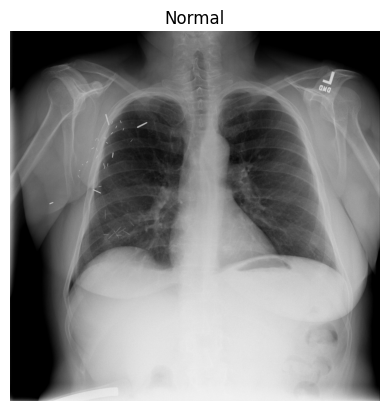

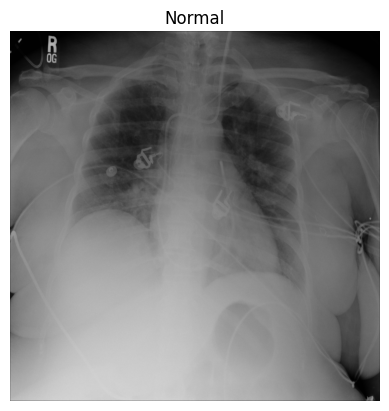

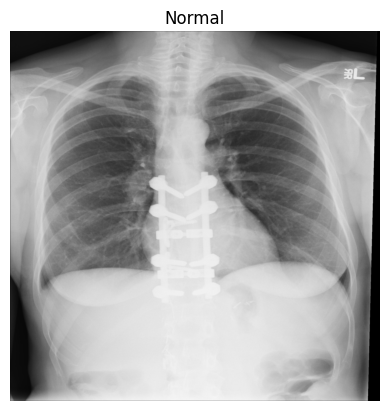

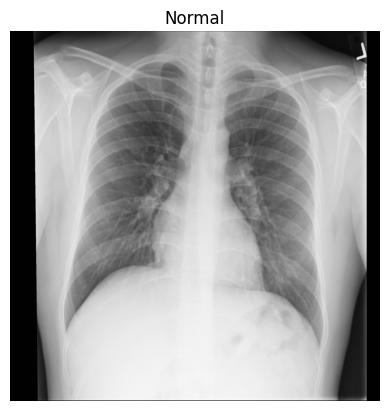

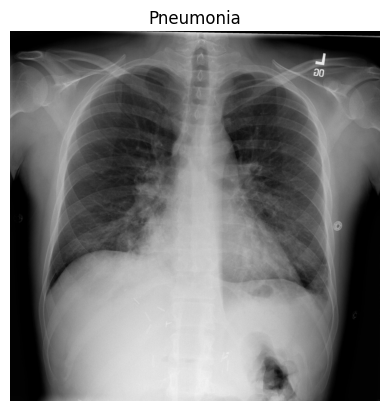

In [7]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

In [8]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


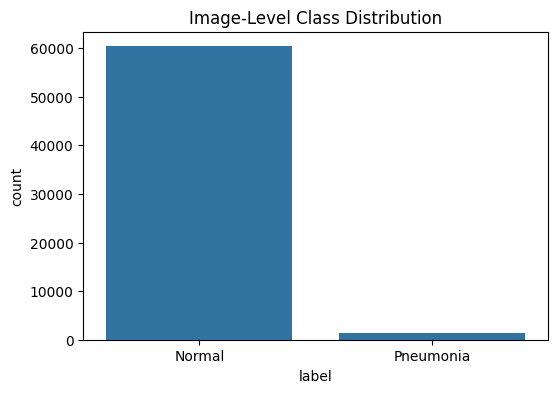

In [9]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


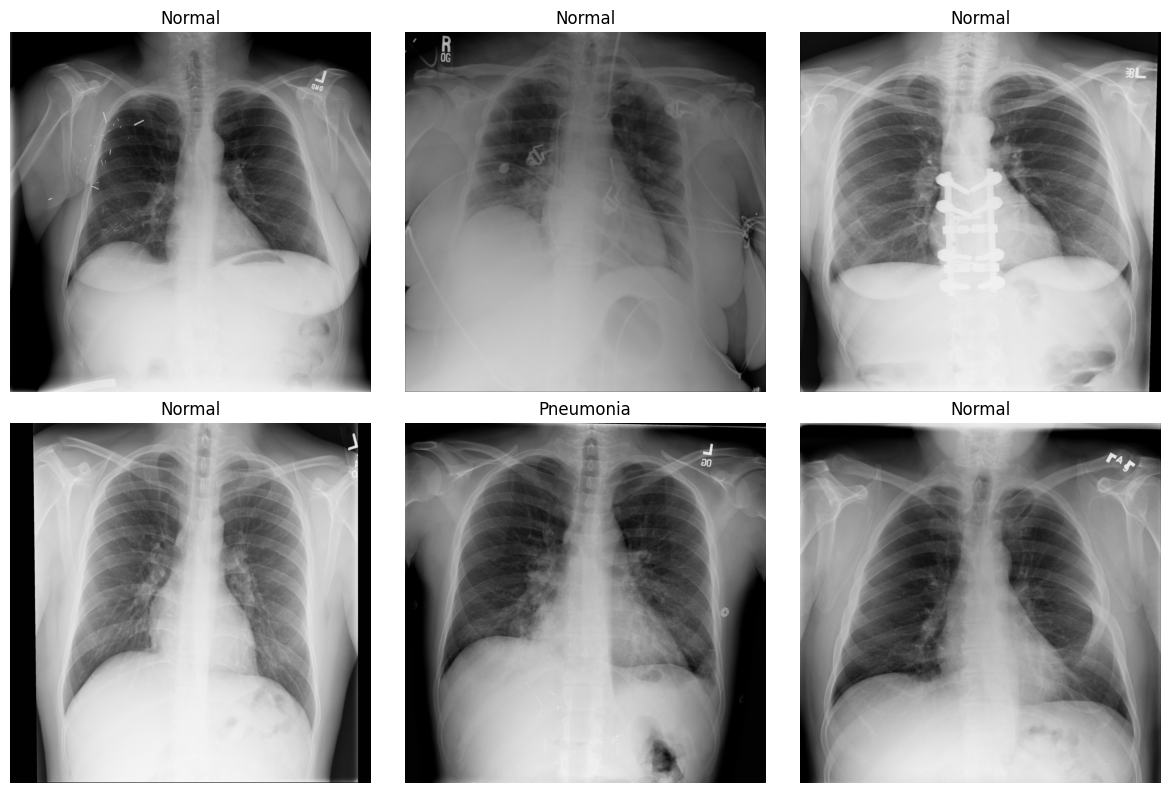

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [13]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [14]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


Original TRAIN distribution:
Counter({0: 42043, 1: 975})


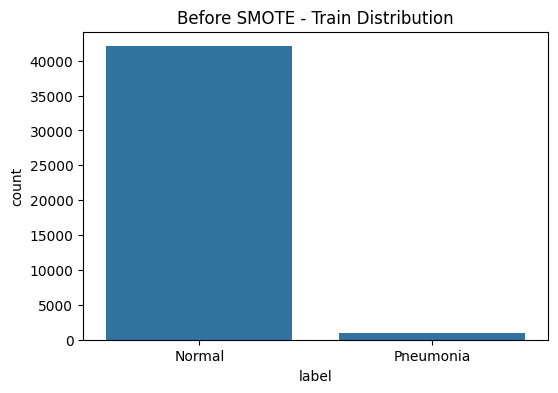


After SMOTE:
Counter({0: 42043, 1: 21021})


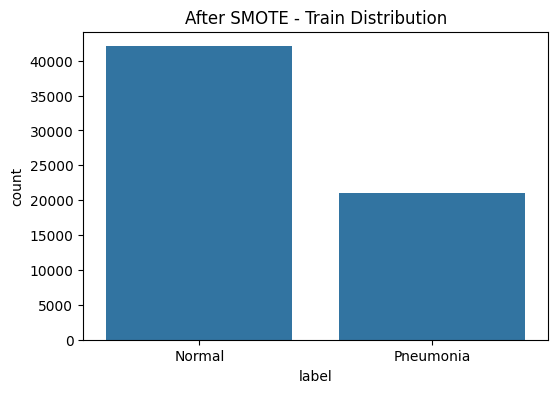


Final image-train distribution:
label
0    42043
1    21021
Name: count, dtype: int64


In [15]:
# =========================
# CLASS IMBALANCE REVIEW
# =========================
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

print("Original TRAIN distribution:")
print(Counter(train_df["label"]))

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("Before SMOTE - Train Distribution")
plt.show()


# ==========================================================
# FEATURE PREP FOR SMOTE
# ==========================================================
# Since SMOTE cannot use image paths directly,
# we use structured metadata for balancing support
# (Age + Gender + View Position)
# ==========================================================

smote_train = train_df.copy()

# Gender
if "Patient Gender" in df.columns:
    gender_map = df[["Image Index", "Patient Gender"]].drop_duplicates()
    gender_map["Patient Gender"] = gender_map["Patient Gender"].map({"M":0, "F":1})
    smote_train = smote_train.merge(
        gender_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Gender"] = 0

# Age
if "Patient Age" in df.columns:
    age_map = df[["Image Index", "Patient Age"]].drop_duplicates()
    smote_train = smote_train.merge(
        age_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Age"] = 50

# View
smote_train["View Position"] = smote_train["View Position"].map({"PA":0, "AP":1})

# Fill
smote_train["Patient Age"] = smote_train["Patient Age"].fillna(smote_train["Patient Age"].median())
smote_train["Patient Gender"] = smote_train["Patient Gender"].fillna(0)

X_train_smote = smote_train[["Patient Age", "Patient Gender", "View Position"]]
y_train_smote = smote_train["label"]


# =========================
# APPLY SMOTE
# =========================
smote = SMOTE(
    sampling_strategy=0.5,   # minority becomes 50% of majority
    random_state=SEED,
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

print("\nAfter SMOTE:")
print(Counter(y_resampled))


# =========================
# VISUALIZE
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("After SMOTE - Train Distribution")
plt.show()


# =========================
# BUILD BALANCED TRAIN DF
# =========================
normal_df = train_df[train_df["label"] == 0].copy()
pneumonia_df = train_df[train_df["label"] == 1].copy()

target_pneumonia = Counter(y_resampled)[1]

pneumonia_upsampled = pneumonia_df.sample(
    n=target_pneumonia,
    replace=True,
    random_state=SEED
)

train_df_balanced = pd.concat(
    [normal_df, pneumonia_upsampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nFinal image-train distribution:")
print(train_df_balanced["label"].value_counts())

In [25]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [28]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch label distribution: (array([0., 1.], dtype=float32), array([30,  2]))


# KNN


Extracting features from training set...

✓ Training Data Extracted Successfully!
  Training features shape: (43018, 114)
  Training labels shape: (43018,)
  Class distribution: [42043   975]


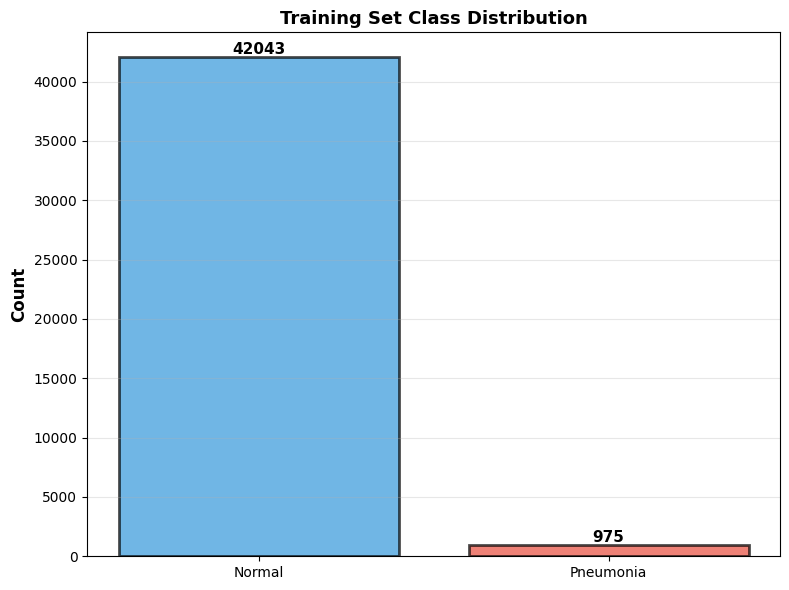


✓ Output: knn_train_distribution.png



In [33]:
print("\nExtracting features from training set...")
train_features_list = []
train_labels_list = []

for images, labels in train_gen:
    # FIX: remove .numpy() here
    images = preprocess_images(images)
    labels = preprocess_labels(labels)
    
    features = extract_features(images)
    
    train_features_list.append(features)
    train_labels_list.append(labels)

X_train = np.concatenate(train_features_list, axis=0)
y_train = np.concatenate(train_labels_list, axis=0)

print(f"\n✓ Training Data Extracted Successfully!")
print(f"  Training features shape: {X_train.shape}")
print(f"  Training labels shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train)}")

# Plot training data distribution
fig, ax = plt.subplots(figsize=(8, 6))
classes = ['Normal', 'Pneumonia']
counts = np.bincount(y_train)
colors = ['#3498db', '#e74c3c']

bars = ax.bar(classes, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Training Set Class Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('knn_train_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Output: knn_train_distribution.png\n")


✓ Validation Data Extracted Successfully!
  Validation features shape: (9271, 114)
  Validation labels shape: (9271,)
  Class distribution: [9070  201]


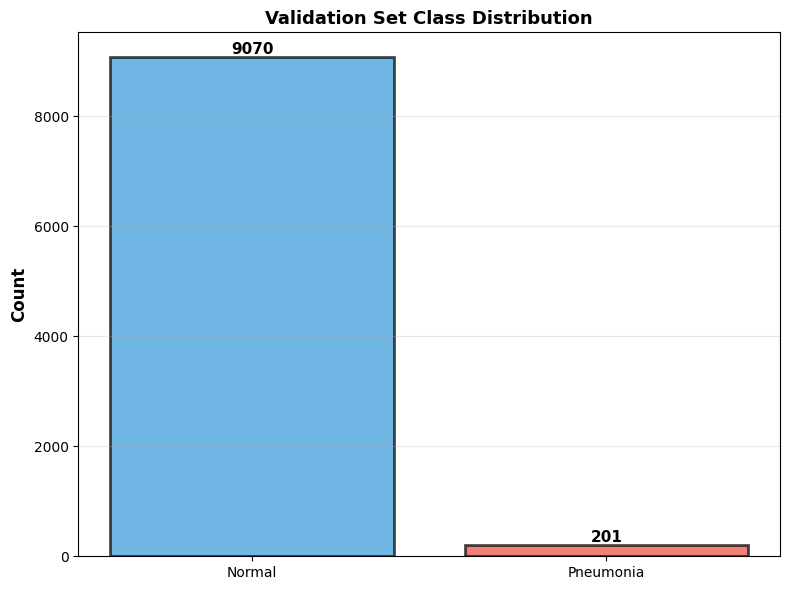


✓ Output: knn_val_distribution.png



In [35]:
val_features_list = []
val_labels_list = []

for images, labels in val_gen:
    # FIX: remove .numpy()
    images = preprocess_images(images)
    labels = preprocess_labels(labels)
    
    features = extract_features(images)
    
    val_features_list.append(features)
    val_labels_list.append(labels)

X_val = np.concatenate(val_features_list, axis=0)
y_val = np.concatenate(val_labels_list, axis=0)

print(f"\n✓ Validation Data Extracted Successfully!")
print(f"  Validation features shape: {X_val.shape}")
print(f"  Validation labels shape: {y_val.shape}")
print(f"  Class distribution: {np.bincount(y_val)}")

# Plot validation data distribution
fig, ax = plt.subplots(figsize=(8, 6))
classes = ['Normal', 'Pneumonia']
counts = np.bincount(y_val)
colors = ['#3498db', '#e74c3c']

bars = ax.bar(classes, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Validation Set Class Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('knn_val_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Output: knn_val_distribution.png\n")


✓ Test Data Extracted Successfully!
  Test features shape: (9503, 114)
  Test labels shape: (9503,)
  Class distribution: [9248  255]


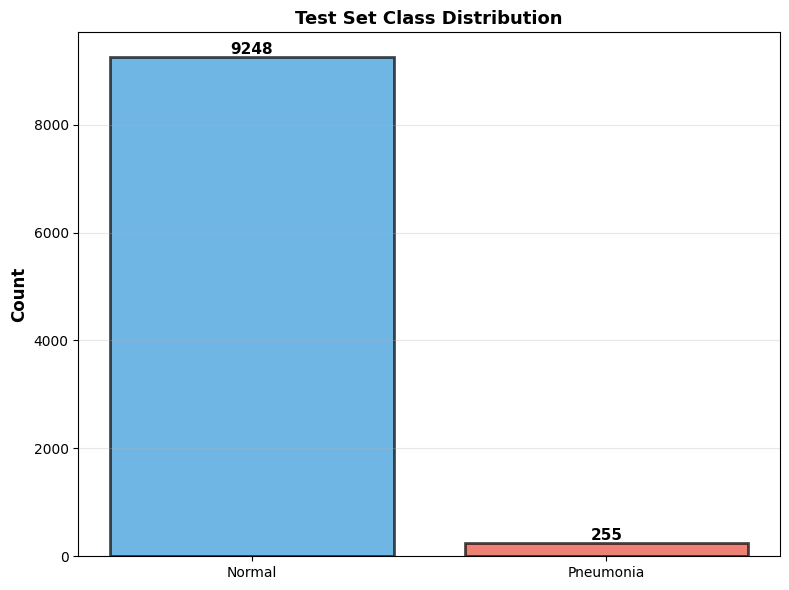


✓ Output: knn_test_distribution.png



In [37]:
test_features_list = []
test_labels_list = []

for images, labels in test_gen:
    # FIX: remove .numpy()
    images = preprocess_images(images)
    labels = preprocess_labels(labels)
    
    features = extract_features(images)
    
    test_features_list.append(features)
    test_labels_list.append(labels)

X_test = np.concatenate(test_features_list, axis=0)
y_test = np.concatenate(test_labels_list, axis=0)

print(f"\n✓ Test Data Extracted Successfully!")
print(f"  Test features shape: {X_test.shape}")
print(f"  Test labels shape: {y_test.shape}")
print(f"  Class distribution: {np.bincount(y_test)}")

# Plot test data distribution
fig, ax = plt.subplots(figsize=(8, 6))
classes = ['Normal', 'Pneumonia']
counts = np.bincount(y_test)
colors = ['#3498db', '#e74c3c']

bars = ax.bar(classes, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Test Set Class Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('knn_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Output: knn_test_distribution.png\n")

✓ Features standardized successfully!

Scaling Statistics:
  Feature means (before): [0.508  0.2251 0.9102 0.0101 0.0835]
  Feature stds (before):  [0.0911 0.044  0.0864 0.0259 0.07  ]

  Feature means (after):  [-0.  0. -0.  0.  0.]
  Feature stds (after):   [1. 1. 1. 1. 1.]


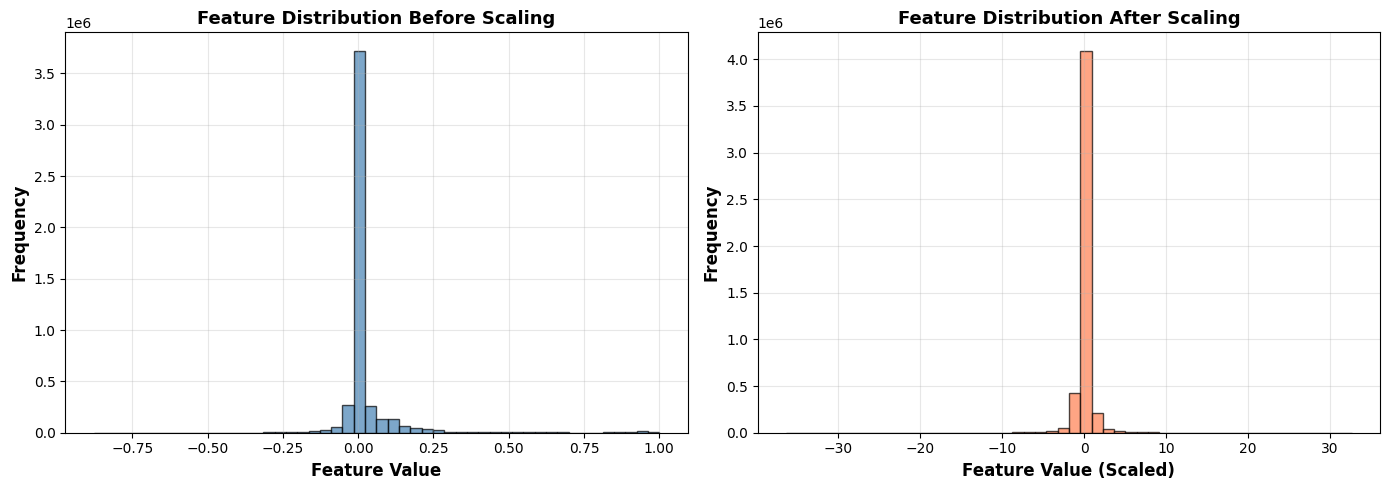


✓ Output: knn_feature_scaling.png

Dataset Summary After Scaling:
  Train: (43018, 114)
  Val:   (9271, 114)
  Test:  (9503, 114)



In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized successfully!")
print(f"\nScaling Statistics:")
print(f"  Feature means (before): {X_train.mean(axis=0)[:5].round(4)}")
print(f"  Feature stds (before):  {X_train.std(axis=0)[:5].round(4)}")
print(f"\n  Feature means (after):  {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"  Feature stds (after):   {X_train_scaled.std(axis=0)[:5].round(4)}")

# Visualize feature scaling effect

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling (flatten)
axes[0].hist(X_train.flatten(), bins=50, alpha=0.7,
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Feature Value', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Feature Distribution Before Scaling', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# After scaling (flatten)
axes[1].hist(X_train_scaled.flatten(), bins=50, alpha=0.7,
             color='coral', edgecolor='black')
axes[1].set_xlabel('Feature Value (Scaled)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Distribution After Scaling', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_feature_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Output: knn_feature_scaling.png")
print(f"\nDataset Summary After Scaling:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}\n")

Training KNN with K=3... ✓ Acc=0.9758, F1=0.9665
Training KNN with K=5... ✓ Acc=0.9780, F1=0.9674
Training KNN with K=7... ✓ Acc=0.9782, F1=0.9675
Training KNN with K=9... ✓ Acc=0.9783, F1=0.9676
Training KNN with K=11... ✓ Acc=0.9783, F1=0.9676
Training KNN with K=15... ✓ Acc=0.9783, F1=0.9676
Training KNN with K=21... ✓ Acc=0.9783, F1=0.9676
Training KNN with K=31... ✓ Acc=0.9783, F1=0.9676

 K  Accuracy  F1-Score
 3  0.975839  0.966547
 5  0.977996  0.967436
 7  0.978212  0.967544
 9  0.978319  0.967598
11  0.978319  0.967598
15  0.978319  0.967598
21  0.978319  0.967598
31  0.978319  0.967598

OPTIMAL K VALUE: 9
Accuracy: 0.9783
F1-Score: 0.9676


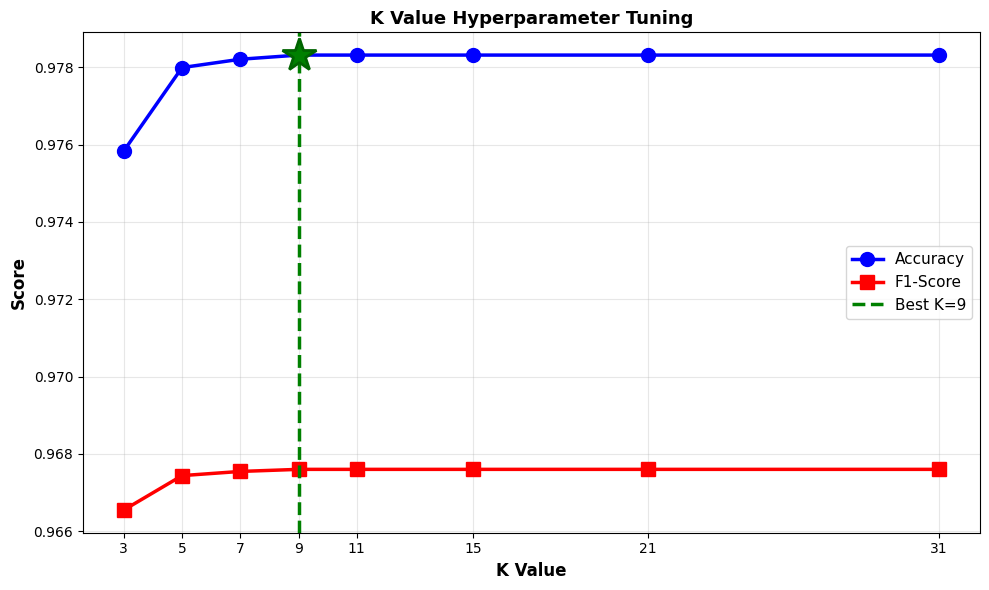


✓ Output: knn_k_selection.png



In [40]:
k_values = [3, 5, 7, 9, 11, 15, 21, 31]
val_accuracies = []
val_f1_scores = []

# Create a table to display results
results_data = []

for k in k_values:
    print(f"Training KNN with K={k}...", end=" ")
    
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    
    y_val_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    val_accuracies.append(acc)
    val_f1_scores.append(f1)
    
    results_data.append({
        'K': k,
        'Accuracy': acc,
        'F1-Score': f1
    })
    
    print(f"✓ Acc={acc:.4f}, F1={f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results_data)
print(f"\n{results_df.to_string(index=False)}")

# Find best K
best_k_idx = np.argmax(val_accuracies)
best_k = k_values[best_k_idx]
best_acc = val_accuracies[best_k_idx]
best_f1 = val_f1_scores[best_k_idx]

print(f"\n{'='*70}")
print(f"OPTIMAL K VALUE: {best_k}")
print(f"Accuracy: {best_acc:.4f}")
print(f"F1-Score: {best_f1:.4f}")
print(f"{'='*70}")

# Plot K vs Performance
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, val_accuracies, 'b-o', label='Accuracy', linewidth=2.5, markersize=10)
ax.plot(k_values, val_f1_scores, 'r-s', label='F1-Score', linewidth=2.5, markersize=10)
ax.axvline(x=best_k, color='green', linestyle='--', linewidth=2.5, label=f'Best K={best_k}')

# Highlight best point
ax.plot(best_k, best_acc, 'g*', markersize=25, markeredgecolor='darkgreen', markeredgewidth=2)

ax.set_xlabel('K Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('K Value Hyperparameter Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_k_selection.png\n")

✓ KNN model trained successfully!

Model Details:
  Algorithm: K-Nearest Neighbors
  K (neighbors): 9
  Metric: Euclidean distance
  Training samples: 43018
  Feature dimensions: 114
  Classes: 2 (Normal, Pneumonia)

Training Performance:
  Accuracy: 0.9774
  F1-Score: 0.9662

Validation Performance:
  Accuracy: 0.9783
  F1-Score: 0.9676


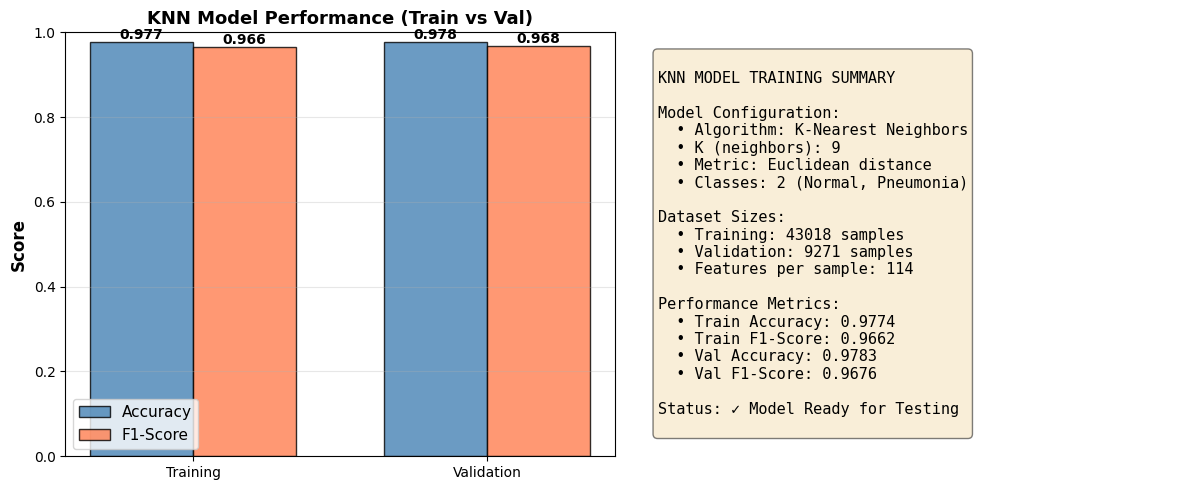


✓ Output: knn_model_training_summary.png



In [41]:
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

print("✓ KNN model trained successfully!")
print(f"\nModel Details:")
print(f"  Algorithm: K-Nearest Neighbors")
print(f"  K (neighbors): {best_k}")
print(f"  Metric: Euclidean distance")
print(f"  Training samples: {X_train_scaled.shape[0]}")
print(f"  Feature dimensions: {X_train_scaled.shape[1]}")
print(f"  Classes: 2 (Normal, Pneumonia)")

# Get training predictions
y_train_pred = knn_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nTraining Performance:")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  F1-Score: {train_f1:.4f}")

# Get validation predictions
y_val_pred = knn_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nValidation Performance:")
print(f"  Accuracy: {val_acc:.4f}")
print(f"  F1-Score: {val_f1:.4f}")

# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datasets = ['Training', 'Validation']
accuracies = [train_acc, val_acc]
f1_scores = [train_f1, val_f1]

x = np.arange(len(datasets))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = axes[0].bar(x + width/2, f1_scores, width, label='F1-Score', color='coral', alpha=0.8, edgecolor='black')

axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('KNN Model Performance (Train vs Val)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Model summary
axes[1].axis('off')
summary_text = f"""
KNN MODEL TRAINING SUMMARY

Model Configuration:
  • Algorithm: K-Nearest Neighbors
  • K (neighbors): {best_k}
  • Metric: Euclidean distance
  • Classes: 2 (Normal, Pneumonia)

Dataset Sizes:
  • Training: {len(y_train)} samples
  • Validation: {len(y_val)} samples
  • Features per sample: {X_train_scaled.shape[1]}

Performance Metrics:
  • Train Accuracy: {train_acc:.4f}
  • Train F1-Score: {train_f1:.4f}
  • Val Accuracy: {val_acc:.4f}
  • Val F1-Score: {val_f1:.4f}

Status: ✓ Model Ready for Testing
"""

axes[1].text(0.05, 0.95, summary_text, transform=axes[1].transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('knn_model_training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_model_training_summary.png\n")

✓ Predictions generated!
  Predicted labels shape: (9503,)
  Predicted probabilities shape: (9503, 2)

Test Set Performance:
  Accuracy:  0.9732
  Precision: 0.9471
  Recall:    0.9732
  F1-Score:  0.9599

Prediction Distribution:
  Normal: 9503 (100.0%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9732    1.0000    0.9864      9248
   Pneumonia     0.0000    0.0000    0.0000       255

    accuracy                         0.9732      9503
   macro avg     0.4866    0.5000    0.4932      9503
weighted avg     0.9471    0.9732    0.9599      9503



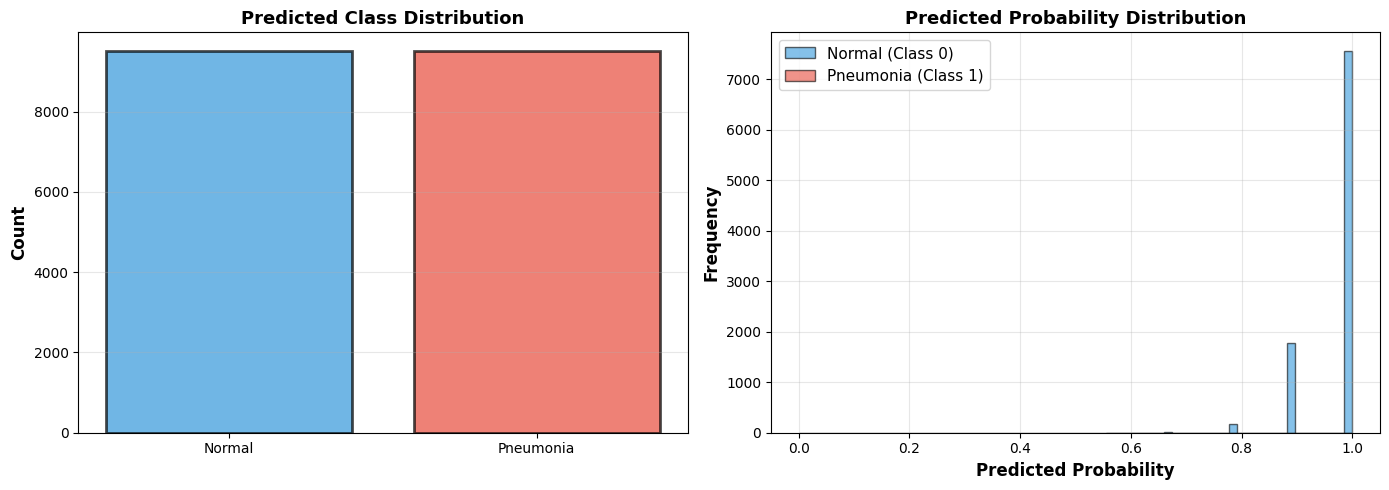


✓ Output: knn_test_predictions.png



In [42]:
y_test_pred = knn_model.predict(X_test_scaled)
y_test_proba = knn_model.predict_proba(X_test_scaled)

print(f"✓ Predictions generated!")
print(f"  Predicted labels shape: {y_test_pred.shape}")
print(f"  Predicted probabilities shape: {y_test_proba.shape}")

# Calculate basic metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Prediction distribution
unique, counts = np.unique(y_test_pred, return_counts=True)
print(f"\nPrediction Distribution:")
for label, count in zip(unique, counts):
    pct = count / len(y_test_pred) * 100
    class_name = 'Normal' if label == 0 else 'Pneumonia'
    print(f"  {class_name}: {count} ({pct:.1f}%)")

# Classification report
print(f"\n{'='*70}")
print("CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Normal', 'Pneumonia'],
                          digits=4))

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction distribution
axes[0].bar(['Normal', 'Pneumonia'], counts, color=['#3498db', '#e74c3c'], 
            alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Predicted Class Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Probability distribution
axes[1].hist(y_test_proba[y_test_pred == 0, 0], bins=30, alpha=0.6, 
             label='Normal (Class 0)', color='#3498db', edgecolor='black')
axes[1].hist(y_test_proba[y_test_pred == 1, 1], bins=30, alpha=0.6, 
             label='Pneumonia (Class 1)', color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_test_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_test_predictions.png\n")


Confusion Matrix:
[[9248    0]
 [ 255    0]]

Confusion Matrix Breakdown:
  True Negatives (TN):  9248
  False Positives (FP): 0
  False Negatives (FN): 255
  True Positives (TP):  0

DETAILED PERFORMANCE METRICS

Classification Metrics:
  Accuracy:    0.9732
  Precision:   0.9471
  Recall:      0.9732
  F1-Score:    0.9599

Sensitivity & Specificity:
  Sensitivity (True Positive Rate):  0.0000
  Specificity (True Negative Rate):  1.0000
  False Positive Rate:               0.0000
  False Negative Rate:               1.0000

Robustness Metrics:
  ROC-AUC:     0.5747
  AP:          0.0353
  MCC:         0.0000
  Kappa:       0.0000


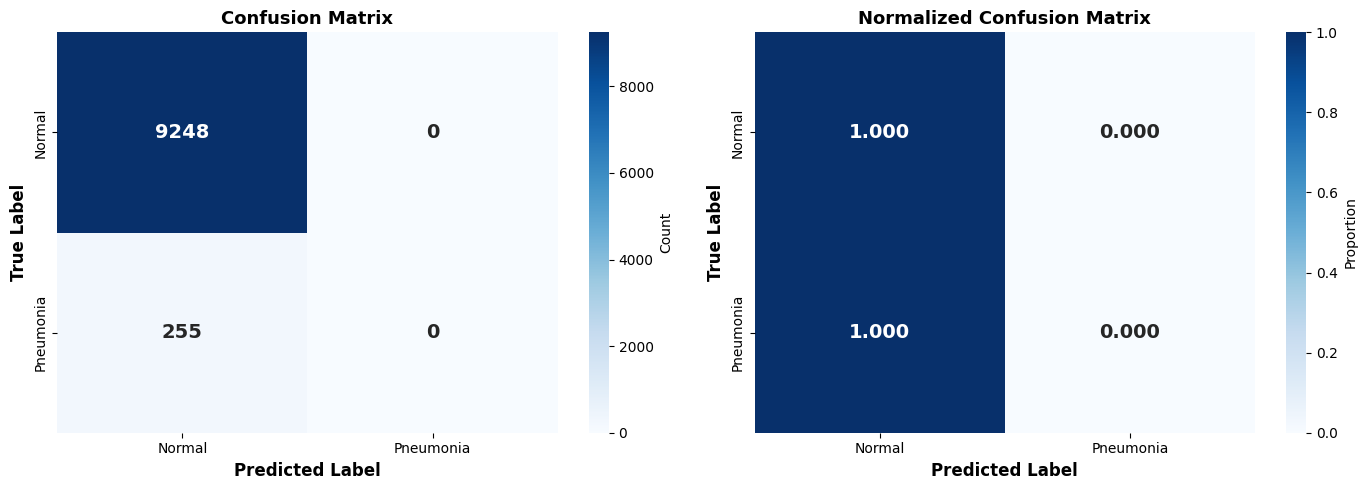

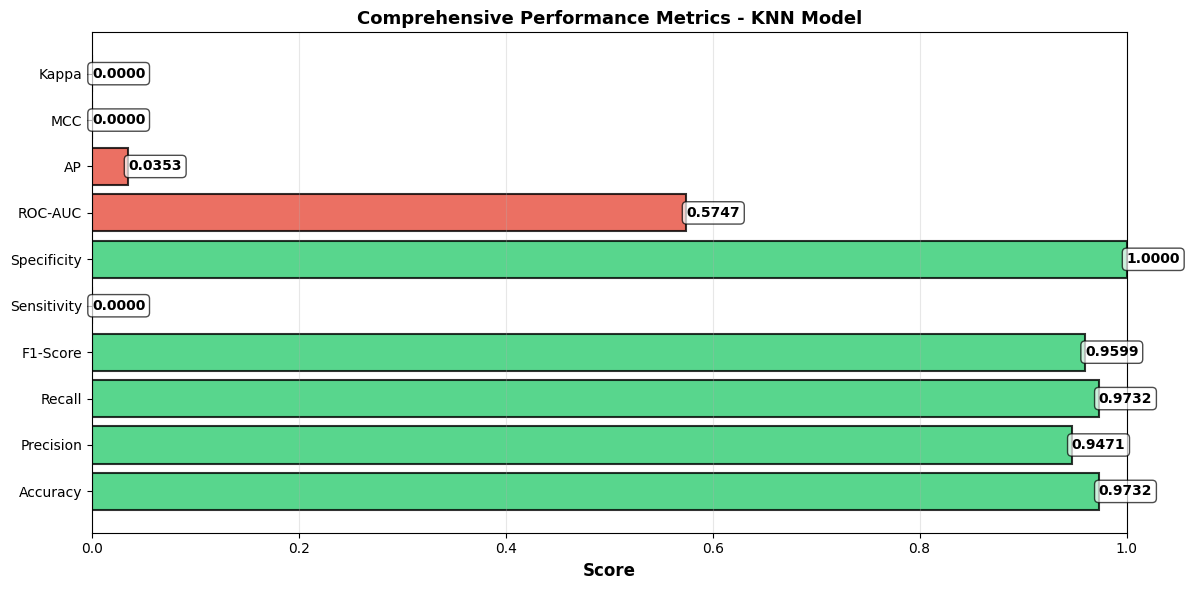


✓ Output: knn_confusion_matrices.png
✓ Output: knn_detailed_metrics.png



In [43]:
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Calculate detailed metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

# Derived metrics
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\n{'='*70}")
print("DETAILED PERFORMANCE METRICS")
print(f"{'='*70}")

print(f"\nClassification Metrics:")
print(f"  Accuracy:    {test_accuracy:.4f}")
print(f"  Precision:   {test_precision:.4f}")
print(f"  Recall:      {test_recall:.4f}")
print(f"  F1-Score:    {test_f1:.4f}")

print(f"\nSensitivity & Specificity:")
print(f"  Sensitivity (True Positive Rate):  {sensitivity:.4f}")
print(f"  Specificity (True Negative Rate):  {specificity:.4f}")
print(f"  False Positive Rate:               {false_positive_rate:.4f}")
print(f"  False Negative Rate:               {false_negative_rate:.4f}")

# Additional metrics
roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])
ap = average_precision_score(y_test, y_test_proba[:, 1])
mcc = matthews_corrcoef(y_test, y_test_pred)
kappa = cohen_kappa_score(y_test, y_test_pred)

print(f"\nRobustness Metrics:")
print(f"  ROC-AUC:     {roc_auc:.4f}")
print(f"  AP:          {ap:.4f}")
print(f"  MCC:         {mcc:.4f}")
print(f"  Kappa:       {kappa:.4f}")

# Store metrics
knn_metrics = {
    'accuracy': test_accuracy,
    'precision': test_precision,
    'recall': test_recall,
    'f1': test_f1,
    'roc_auc': roc_auc,
    'ap': ap,
    'mcc': mcc,
    'kappa': kappa,
    'sensitivity': sensitivity,
    'specificity': specificity
}

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[0], cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Plot 2: Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[1], cbar_kws={'label': 'Proportion'}, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('knn_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize detailed metrics
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Sensitivity', 
                'Specificity', 'ROC-AUC', 'AP', 'MCC', 'Kappa']
metrics_values = [test_accuracy, test_precision, test_recall, test_f1, sensitivity,
                 specificity, roc_auc, ap, mcc, kappa]

colors = ['#2ecc71' if v > 0.8 else '#f39c12' if v > 0.6 else '#e74c3c' for v in metrics_values]
bars = ax.barh(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Performance Metrics - KNN Model', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}',
            ha='left', va='center', fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', 
            facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('knn_detailed_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_confusion_matrices.png")
print(f"✓ Output: knn_detailed_metrics.png\n")

ROC-AUC Score: 0.5747

Threshold Analysis:
  Number of thresholds: 6
  Default threshold: 0.5
  Optimal threshold (Youden): 0.1111
    TPR at optimal: 0.3451
    FPR at optimal: 0.2013


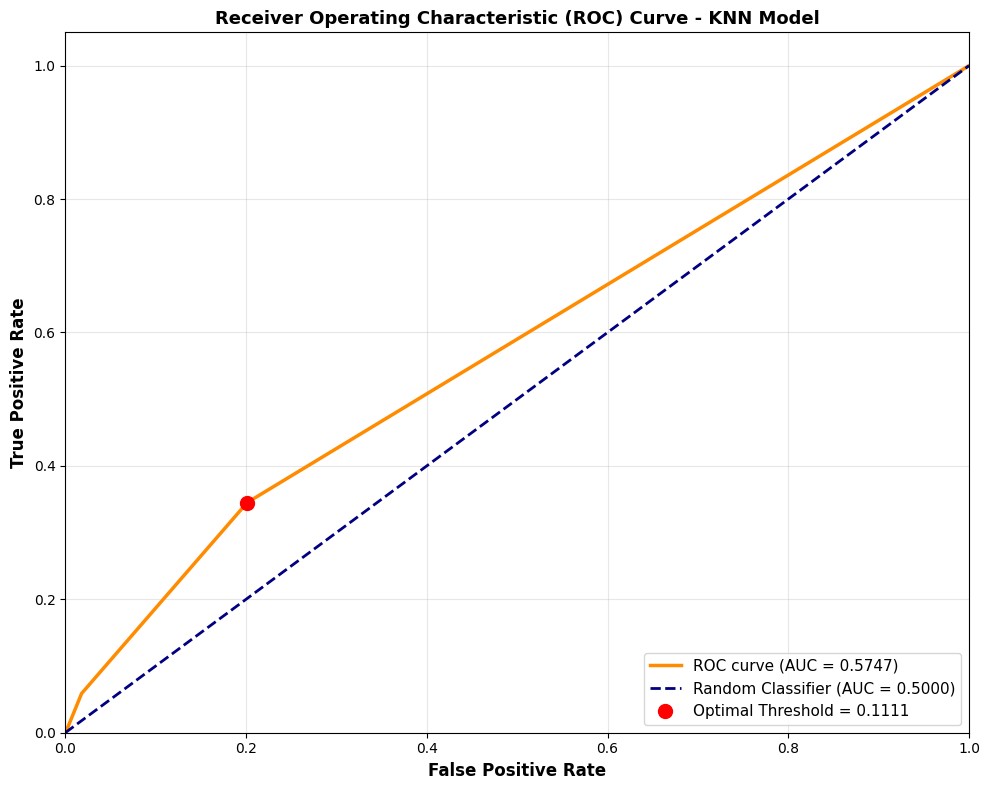


✓ Output: knn_roc_curve.png



In [44]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"\nThreshold Analysis:")
print(f"  Number of thresholds: {len(thresholds)}")
print(f"  Default threshold: 0.5")

# Find best threshold (Youden's J statistic)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

print(f"  Optimal threshold (Youden): {best_threshold:.4f}")
print(f"    TPR at optimal: {best_tpr:.4f}")
print(f"    FPR at optimal: {best_fpr:.4f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
ax.plot(best_fpr, best_tpr, 'ro', markersize=10, label=f'Optimal Threshold = {best_threshold:.4f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC) Curve - KNN Model', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_roc_curve.png\n")

In [ ]:
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance on test set...")
perm_importance = permutation_importance(
    knn_model, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Get top 20 features
importance_df = pd.DataFrame({
    'Feature': range(len(perm_importance.importances_mean)),
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False).head(20)

print("\nTop 20 Most Important Features:")
print(importance_df.to_string(index=False))

# Plot permutation importance
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(importance_df))
ax.barh(y_pos, importance_df['Importance'], 
        xerr=importance_df['Std'], color='steelblue', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"Feature {int(i)}" for i in importance_df['Feature']])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Permutation Feature Importance - KNN', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('knn_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Permutation importance computed and saved!")
print("✓ Output: knn_permutation_importance.png\n")


Computing permutation importance on test set...


Average Precision (AP): 0.0353
Baseline (Random): 0.0268
Improvement over baseline: 0.0084

Optimal Threshold (F1-based): 0.1111
  Precision at optimal: 0.0451
  Recall at optimal: 0.3451


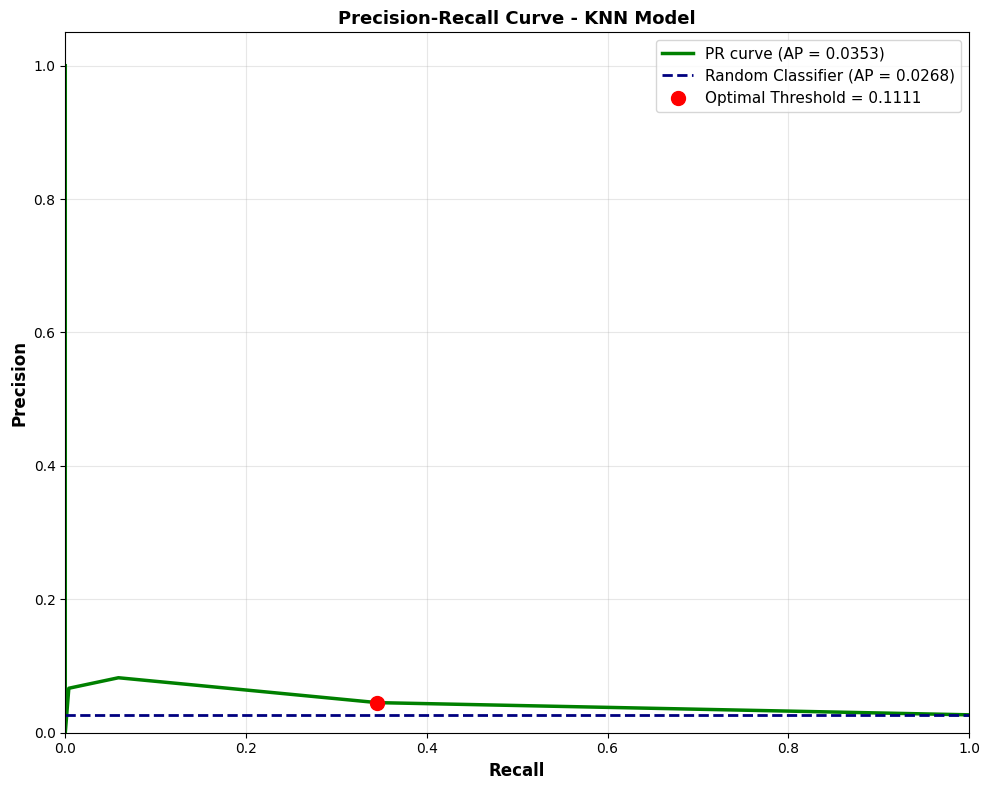


✓ Output: knn_precision_recall_curve.png



In [45]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_test_proba[:, 1])
ap = average_precision_score(y_test, y_test_proba[:, 1])

print(f"Average Precision (AP): {ap:.4f}")
print(f"Baseline (Random): {np.mean(y_test):.4f}")
print(f"Improvement over baseline: {(ap - np.mean(y_test)):.4f}")

# Find best threshold on PR curve
f1_scores_pr = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
best_idx_pr = np.argmax(f1_scores_pr)
best_threshold_pr = thresholds_pr[best_idx_pr] if best_idx_pr < len(thresholds_pr) else 0.5
best_precision = precision_vals[best_idx_pr]
best_recall = recall_vals[best_idx_pr]

print(f"\nOptimal Threshold (F1-based): {best_threshold_pr:.4f}")
print(f"  Precision at optimal: {best_precision:.4f}")
print(f"  Recall at optimal: {best_recall:.4f}")

# Plot PR curve
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(recall_vals, precision_vals, color='green', lw=2.5, 
        label=f'PR curve (AP = {ap:.4f})')
ax.axhline(y=np.mean(y_test), color='navy', linestyle='--', lw=2, 
           label=f'Random Classifier (AP = {np.mean(y_test):.4f})')
ax.plot(best_recall, best_precision, 'ro', markersize=10, 
        label=f'Optimal Threshold = {best_threshold_pr:.4f}')

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve - KNN Model', fontsize=13, fontweight='bold')
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('knn_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Output: knn_precision_recall_curve.png\n")

# XAI

Background samples: 100
Computing SHAP values for 10 test samples...


  0%|          | 0/10 [00:00<?, ?it/s]

✓ SHAP values computed!

Generating SHAP summary plot...

Top 15 SHAP Feature Importance:
   Feature  Mean |SHAP|
Feature 17     0.000078
 Feature 6     0.000068
Feature 19     0.000066
Feature 36     0.000065
Feature 30     0.000051
 Feature 9     0.000050
Feature 27     0.000049
Feature 21     0.000044
Feature 64     0.000042
Feature 60     0.000042
 Feature 8     0.000000
Feature 10     0.000000
Feature 12     0.000000
 Feature 2     0.000000
 Feature 5     0.000000


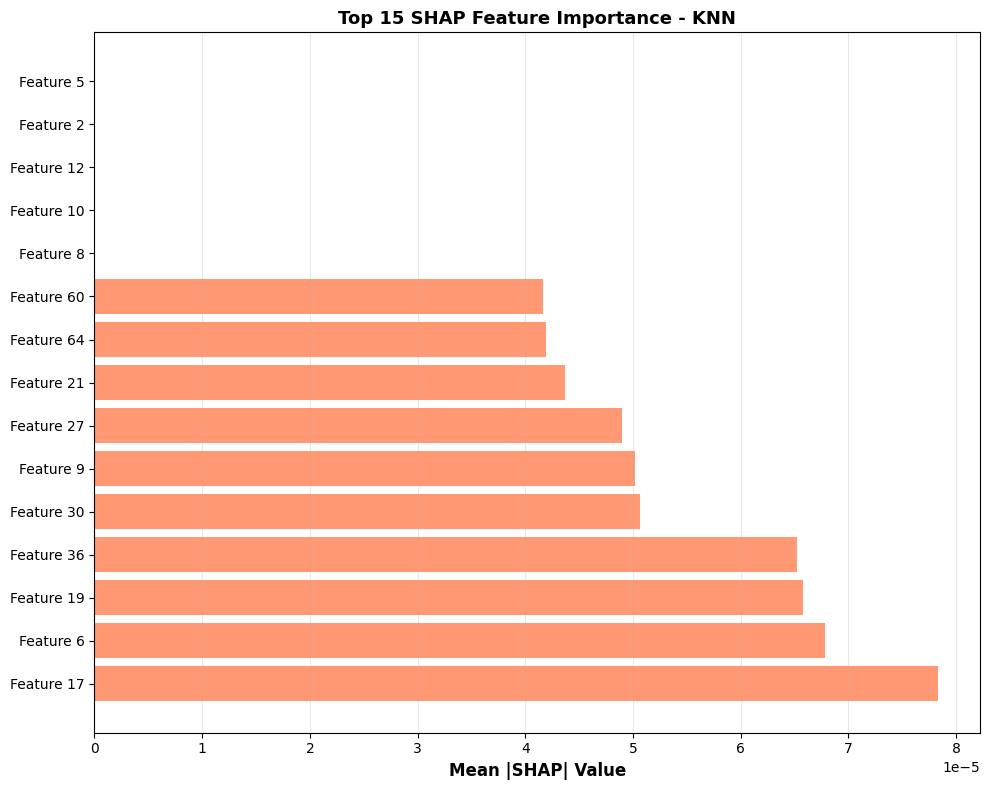


✓ SHAP importance analysis complete!
✓ Output: knn_shap_importance.png



In [48]:
background_indices = np.random.choice(len(X_train_scaled), min(100, len(X_train_scaled)), replace=False)
X_background = X_train_scaled[background_indices]

print(f"Background samples: {len(X_background)}")

# Create SHAP explainer
explainer = shap.KernelExplainer(
    model=knn_model.predict,
    data=shap.sample(X_background, min(50, len(X_background)))
)

# Get test samples for explanation
test_indices = np.random.choice(len(X_test_scaled), min(10, len(X_test_scaled)), replace=False)
X_test_sample = X_test_scaled[test_indices]

print(f"Computing SHAP values for {len(X_test_sample)} test samples...")

shap_values = explainer.shap_values(X_test_sample)

print("✓ SHAP values computed!")

# Feature names
feature_names = [f"Feature {i}" for i in range(X_test_sample.shape[1])]

# SHAP Summary Plot
print("\nGenerating SHAP summary plot...")

fig, ax = plt.subplots(figsize=(10, 8))

# For binary classification, take class 1 (Pneumonia) SHAP values
if isinstance(shap_values, list):
    shap_vals_class1 = np.array(shap_values[1])
else:
    shap_vals_class1 = shap_values

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).head(15)

print("\nTop 15 SHAP Feature Importance:")
print(feature_importance_shap.to_string(index=False))

ax.barh(range(len(feature_importance_shap)), feature_importance_shap['Mean |SHAP|'],
        color='coral', alpha=0.8)
ax.set_yticks(range(len(feature_importance_shap)))
ax.set_yticklabels(feature_importance_shap['Feature'])
ax.set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
ax.set_title('Top 15 SHAP Feature Importance - KNN', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('knn_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SHAP importance analysis complete!")
print("✓ Output: knn_shap_importance.png\n")

Sample 1: True=0, Pred=0, Confidence=0.000
Sample 2: True=0, Pred=0, Confidence=0.000
Sample 3: True=0, Pred=0, Confidence=0.111
Sample 4: True=0, Pred=0, Confidence=0.000


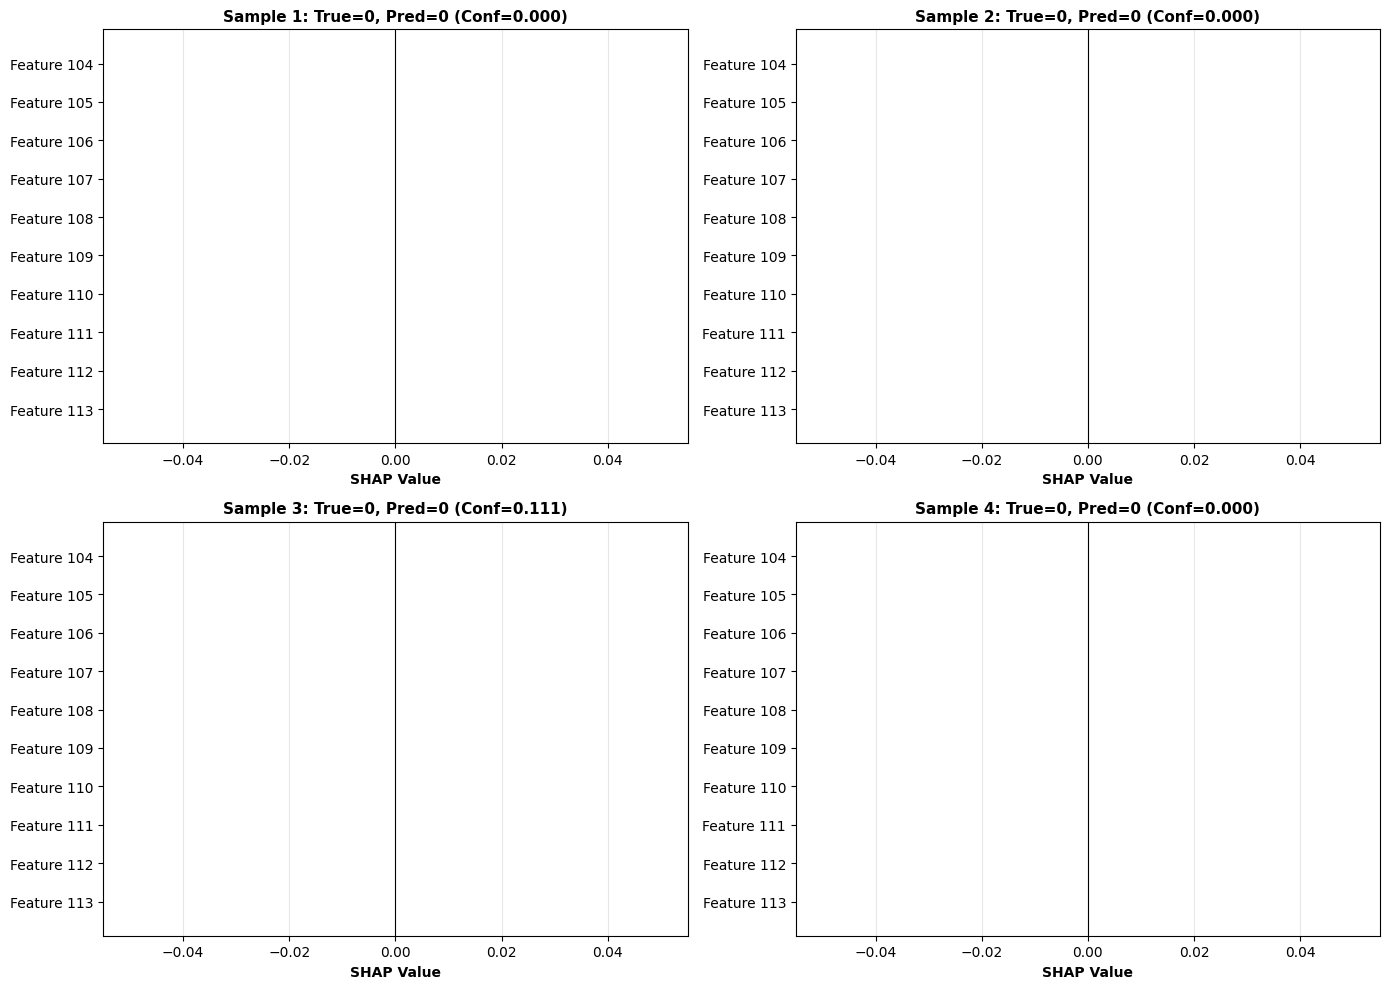


✓ Individual SHAP explanations generated!
✓ Output: knn_shap_individual.png



In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx in range(min(4, len(X_test_sample))):
    ax = axes[idx]
    
    true_label = y_test[test_indices[idx]]
    pred_label = knn_model.predict(X_test_sample[idx:idx+1])[0]
    pred_proba = knn_model.predict_proba(X_test_sample[idx:idx+1])[0][1]
    
    print(f"Sample {idx+1}: True={int(true_label)}, Pred={int(pred_label)}, Confidence={pred_proba:.3f}")
    
    # Get top contributing features
    if isinstance(shap_values, list):
        sample_shap = shap_vals_class1[idx]
    else:
        sample_shap = shap_values[idx]
    
    top_indices = np.argsort(np.abs(sample_shap))[-10:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_shap = sample_shap[top_indices]
    
    colors = ['red' if v > 0 else 'blue' for v in top_shap]
    
    y_pos = np.arange(len(top_features))
    ax.barh(y_pos, top_shap, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features)
    ax.set_xlabel('SHAP Value', fontsize=10, fontweight='bold')
    ax.set_title(f'Sample {idx+1}: True={int(true_label)}, Pred={int(pred_label)} (Conf={pred_proba:.3f})',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('knn_shap_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Individual SHAP explanations generated!")
print("✓ Output: knn_shap_individual.png\n")


Initializing LIME explainer...
Generating LIME explanations for 4 test samples...

Sample 1: True=0, Pred=0, Confidence=0.000
Sample 2: True=0, Pred=0, Confidence=0.000
Sample 3: True=0, Pred=0, Confidence=0.111
Sample 4: True=0, Pred=0, Confidence=0.000


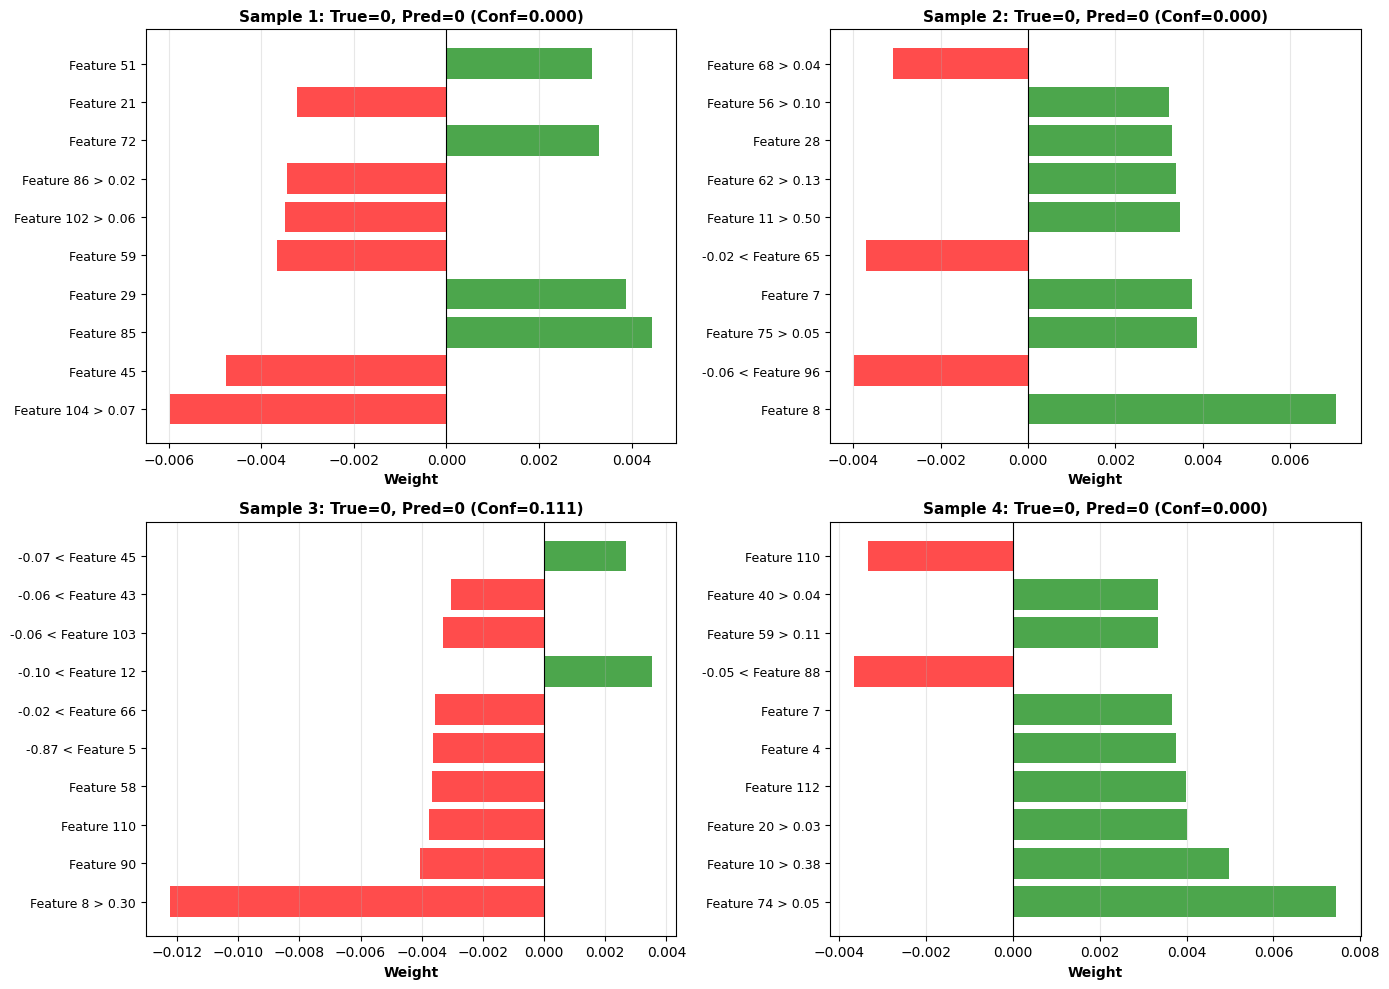


✓ LIME explanations generated!
✓ Output: knn_lime_explanations.png



In [50]:
import lime
import lime.lime_tabular

print("\nInitializing LIME explainer...")

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=['Normal', 'Pneumonia'],
    mode='classification',
    verbose=False
)

print("Generating LIME explanations for 4 test samples...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx in range(min(4, len(X_test_sample))):
    ax = axes[idx]
    
    true_label = y_test[test_indices[idx]]
    pred_label = knn_model.predict(X_test_sample[idx:idx+1])[0]
    pred_proba = knn_model.predict_proba(X_test_sample[idx:idx+1])[0][1]
    
    print(f"Sample {idx+1}: True={int(true_label)}, Pred={int(pred_label)}, Confidence={pred_proba:.3f}")
    
    # Generate LIME explanation
    try:
        explanation = lime_explainer.explain_instance(
            X_test_sample[idx],
            knn_model.predict_proba,
            top_labels=2,
            num_features=10
        )
        
        # Get explanation for predicted class
        exp_list = explanation.as_list(label=pred_label)
        
        features_exp = [item[0] for item in exp_list]
        weights_exp = [item[1] for item in exp_list]
        
        colors_exp = ['green' if w > 0 else 'red' for w in weights_exp]
        
        y_pos = np.arange(len(features_exp))
        ax.barh(y_pos, weights_exp, color=colors_exp, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f.split('<=')[0].strip() if '<=' in f else f for f in features_exp], fontsize=9)
        ax.set_xlabel('Weight', fontsize=10, fontweight='bold')
        ax.set_title(f'Sample {idx+1}: True={int(true_label)}, Pred={int(pred_label)} (Conf={pred_proba:.3f})',
                    fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        ax.axis('off')
        print(f"  Error: {str(e)[:50]}")

plt.tight_layout()
plt.savefig('knn_lime_explanations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ LIME explanations generated!")
print("✓ Output: knn_lime_explanations.png\n")

In [56]:
from sklearn.inspection import permutation_importance
import pandas as pd

print("Computing feature importance using permutation importance...")

perm_importance = permutation_importance(
    knn_model,
    X_val_scaled[:1000],
    y_val[:1000],
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': np.arange(X_train.shape[1]),
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 important features:")
print(importance_df.head(10))

Computing feature importance using permutation importance...

Top 10 important features:
   Feature  Importance
0        0         0.0
1        1         0.0
2        2         0.0
3        3         0.0
4        4         0.0
5        5         0.0
6        6         0.0
7        7         0.0
8        8         0.0
9        9         0.0



Computing PDP for top 4 features: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Computing PDP for Feature 0...
Computing PDP for Feature 1...
Computing PDP for Feature 2...
Computing PDP for Feature 3...


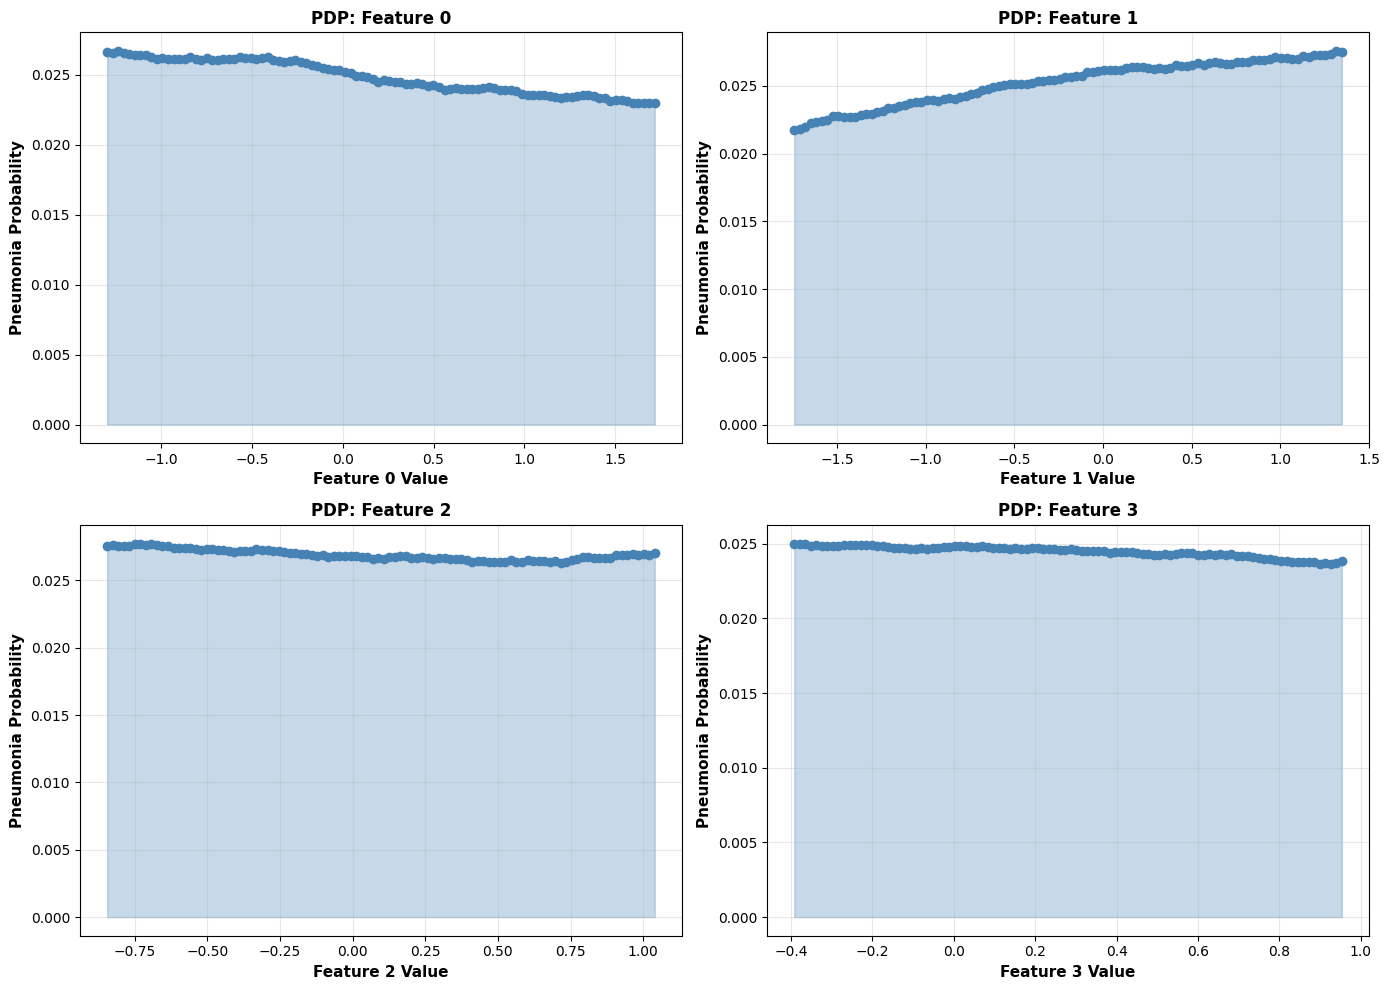


✓ PDP analysis complete!
✓ Output: knn_partial_dependence.png



In [57]:
from sklearn.inspection import partial_dependence

# Select top features for PDP
top_features_indices = importance_df['Feature'].head(4).astype(int).values

print(f"\nComputing PDP for top 4 features: {list(top_features_indices)}\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feat_idx in enumerate(top_features_indices):
    ax = axes[idx]
    
    print(f"Computing PDP for Feature {int(feat_idx)}...")
    
    # Compute partial dependence
    pd_result = partial_dependence(
        knn_model, X_test_scaled, [feat_idx],
        kind='average'
    )
    
    grid_vals = pd_result['grid_values'][0]
    pd_vals = pd_result['average'][0]
    
    ax.plot(grid_vals, pd_vals, color='steelblue', linewidth=2.5, marker='o', markersize=6)
    ax.fill_between(grid_vals, pd_vals, alpha=0.3, color='steelblue')
    ax.set_xlabel(f'Feature {int(feat_idx)} Value', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pneumonia Probability', fontsize=11, fontweight='bold')
    ax.set_title(f'PDP: Feature {int(feat_idx)}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_partial_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ PDP analysis complete!")
print("✓ Output: knn_partial_dependence.png\n")

Computing ICE for Feature 0...
Computing ICE for Feature 1...
Computing ICE for Feature 2...
Computing ICE for Feature 3...


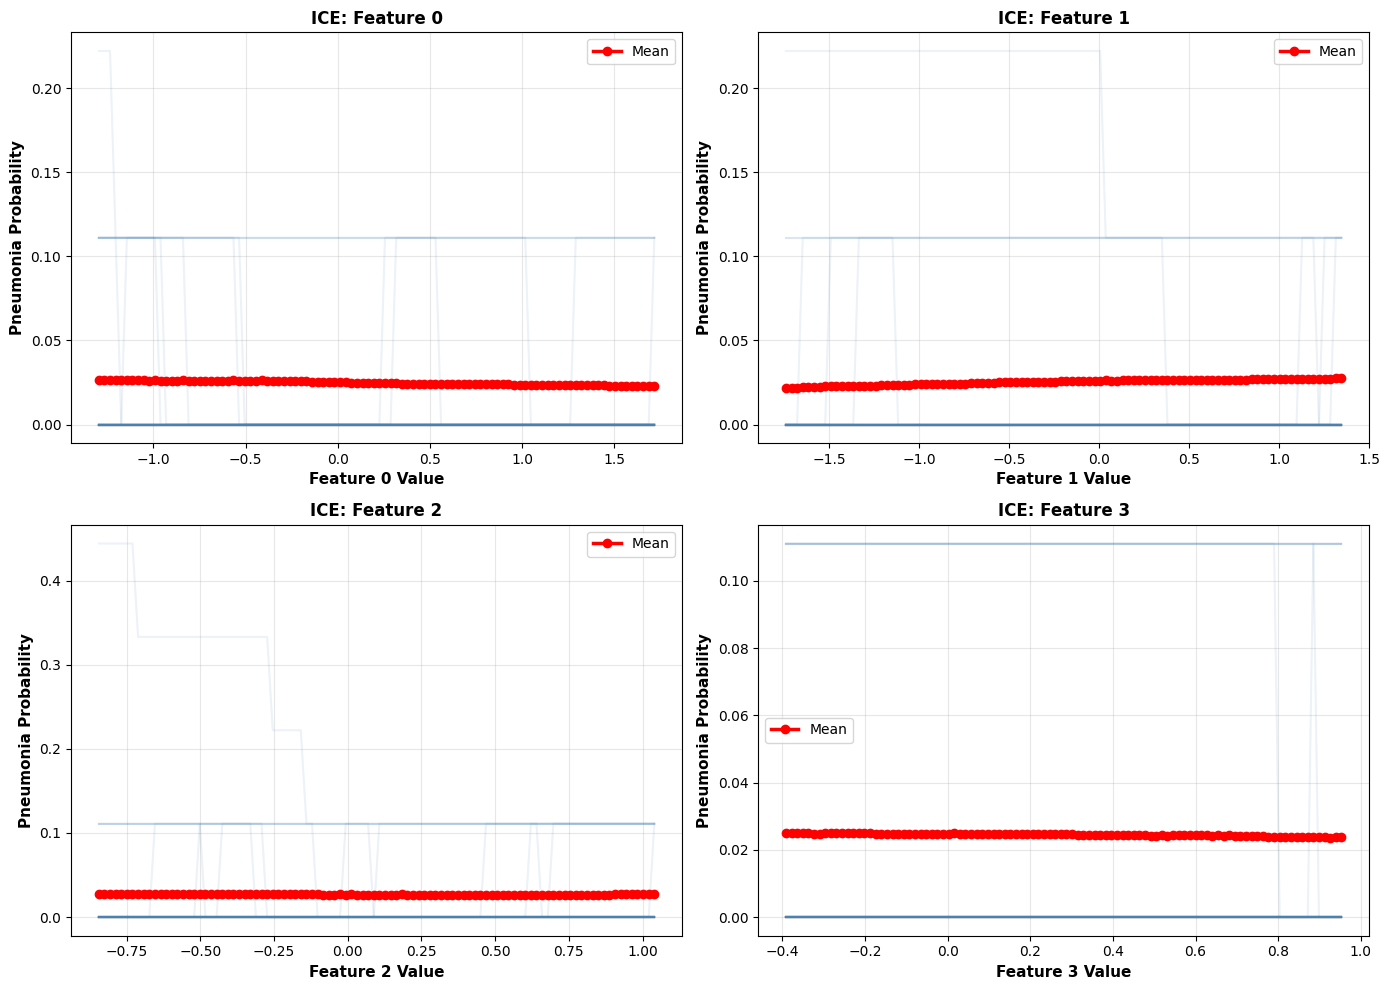


✓ ICE analysis complete!
✓ Output: knn_ice_plots.png



In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feat_idx in enumerate(top_features_indices):
    ax = axes[idx]
    
    print(f"Computing ICE for Feature {int(feat_idx)}...")
    
    # Compute partial dependence with kind='individual'
    pd_result = partial_dependence(
        knn_model, X_test_scaled, [feat_idx],
        kind='individual'
    )
    
    grid_vals = pd_result['grid_values'][0]
    pd_vals = pd_result['individual'][0]
    
    # Plot ICE lines
    for sample_idx in range(min(50, len(pd_vals))):
        ax.plot(grid_vals, pd_vals[sample_idx], color='steelblue', alpha=0.1)
    
    # Plot average
    avg_pd = np.mean(pd_vals, axis=0)
    ax.plot(grid_vals, avg_pd, color='red', linewidth=2.5, label='Mean', marker='o', markersize=6)
    
    ax.set_xlabel(f'Feature {int(feat_idx)} Value', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pneumonia Probability', fontsize=11, fontweight='bold')
    ax.set_title(f'ICE: Feature {int(feat_idx)}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_ice_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ ICE analysis complete!")
print("✓ Output: knn_ice_plots.png\n")


Computing correlations for top 15 features...

Feature Correlation with Pneumonia Diagnosis:
   Feature  Correlation with Pneumonia
 Feature 8                    0.066922
Feature 12                   -0.047761
 Feature 7                    0.040161
Feature 13                   -0.038214
 Feature 0                   -0.031222
 Feature 1                   -0.029252
 Feature 9                    0.028184
Feature 11                   -0.027413
Feature 14                    0.025600
 Feature 5                   -0.022358
 Feature 6                   -0.017983
 Feature 2                    0.015039
 Feature 4                    0.011436
Feature 10                    0.003872
 Feature 3                    0.000356


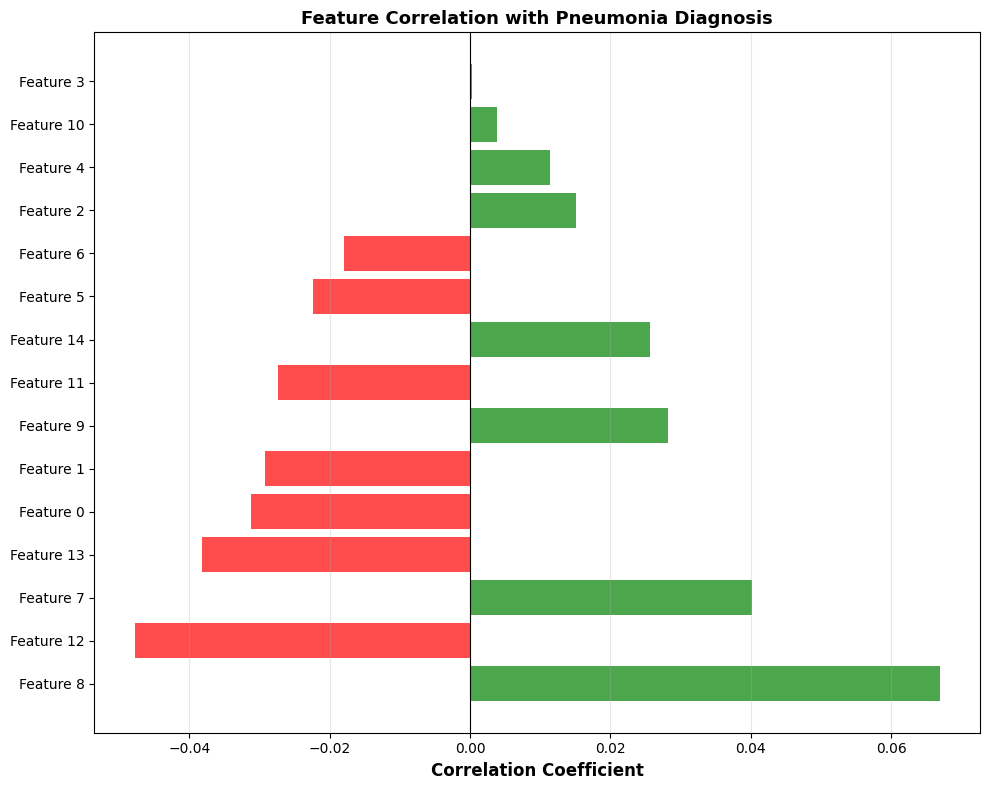


✓ Feature correlation analysis complete!
✓ Output: knn_feature_correlation.png



In [59]:
top_n_features = 15
top_feature_indices = importance_df['Feature'].head(top_n_features).astype(int).values

print(f"\nComputing correlations for top {top_n_features} features...\n")

correlations = []
for feat_idx in top_feature_indices:
    corr = np.corrcoef(X_test_scaled[:, feat_idx], y_test)[0, 1]
    correlations.append(corr)

corr_df = pd.DataFrame({
    'Feature': [f"Feature {int(i)}" for i in top_feature_indices],
    'Correlation with Pneumonia': correlations
}).sort_values('Correlation with Pneumonia', key=abs, ascending=False)

print("Feature Correlation with Pneumonia Diagnosis:")
print(corr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['green' if x > 0 else 'red' for x in corr_df['Correlation with Pneumonia']]
ax.barh(range(len(corr_df)), corr_df['Correlation with Pneumonia'], color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['Feature'])
ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Feature Correlation with Pneumonia Diagnosis', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('knn_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature correlation analysis complete!")
print("✓ Output: knn_feature_correlation.png\n")